# Face Mask Detection — VGG16 Transfer Learning

Same problem as notebook 1, but this time using a pretrained VGG16 instead of building a CNN from scratch.  
The idea: freeze VGG16's layers and only train a single Dense layer on top.

**Why?** Our dataset is tiny (~1,376 images). VGG16 was trained on 14M images — we can borrow those learned features.

## 1. Imports

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from keras.applications.vgg16 import VGG16, preprocess_input
from keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

## 2. Load the Dataset

Same dataset as notebook 1 — two folders, resize to 224x224.

In [3]:
!git clone https://github.com/ricklon/pyimagesearch-face-mask-detector.git

Cloning into 'pyimagesearch-face-mask-detector'...
remote: Enumerating objects: 1311, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 1311 (delta 4), reused 0 (delta 0), pack-reused 1302 (from 1)
Receiving objects: 100% (1311/1311), 68.64 MiB | 23.58 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [4]:
# Clone the dataset (run once)
# !git clone https://github.com/ricklon/pyimagesearch-face-mask-detector.git

dataset_path = "/content/pyimagesearch-face-mask-detector/dataset"
categories = ['without_mask', 'with_mask']   # 0 = no mask, 1 = mask

print("Classes:", os.listdir(dataset_path))

Classes: ['with_mask', 'without_mask']


In [5]:
data = []
for category in categories:
    path = os.path.join(dataset_path, category)
    label = categories.index(category)

    for file in os.listdir(path):
        img_path = os.path.join(path, file)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (224, 224))
        data.append([img, label])

print(f"Total images loaded: {len(data)}")

Total images loaded: 1376


## 3. Preprocess & Split

Important difference from notebook 1: here we use `preprocess_input` instead of `/255`.  
VGG16 expects its specific preprocessing (subtracts ImageNet channel means) — using `/255` here would give bad results because the pretrained weights expect a different input distribution.

In [6]:
random.shuffle(data)

X = np.array([item[0] for item in data])
y = np.array([item[1] for item in data])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Class distribution: no_mask={sum(y==0)}, mask={sum(y==1)}")

X shape: (1376, 224, 224, 3)
y shape: (1376,)
Class distribution: no_mask=686, mask=690


In [7]:
# VGG16 preprocessing — NOT /255
X = preprocess_input(X)

# 70/15/15 split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Train: 963 | Val: 206 | Test: 207


## 4. Build the Model

Take VGG16, chop off the last layer (1000-class softmax), freeze everything, add our own Dense(1).  
We end up with 134M frozen params and only 4,097 trainable params — that's the whole point of transfer learning.

In [8]:
vgg = VGG16()

# copy all layers except the final classification layer
model = Sequential()
for layer in vgg.layers[:-1]:
    model.add(layer)

# freeze everything
for layer in model.layers:
    layer.trainable = False

# our classification head
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,264,641 (512.18 MB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 134,260,544 (512.16 MB)

## 5. Train

Data augmentation + EarlyStopping + ModelCheckpoint.  
Since we're only training 4K params, this is very fast even without heavy augmentation.

In [9]:
datagen = ImageDataGenerator(
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2
)

callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ModelCheckpoint('best_model.keras', save_best_only=True)
]

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=30,
    validation_data=(X_val, y_val),
    callbacks=callbacks
)

Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 44s 980ms/step - accuracy: 0.9107 - loss: 0.1904 - val_accuracy: 0.9854 - val_loss: 0.0359
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 648ms/step - accuracy: 0.9875 - loss: 0.0445 - val_accuracy: 0.9903 - val_loss: 0.0326
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 29s 960ms/step - accuracy: 0.9865 - loss: 0.0372 - val_accuracy: 0.9903 - val_loss: 0.0316
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.9917 - loss: 0.0272 - val_accuracy: 0.9903 - val_loss: 0.0264
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.9938 - loss: 0.0215 - val_accuracy: 0.9903 - val_loss: 0.0166
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 447ms/step - accuracy: 0.9990 - loss: 0.0151 - val_accuracy: 0.9903 - val_loss: 0.0172
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 440ms/step - accuracy: 0.9979 - loss: 0.0155 - val_accuracy: 0.9903 - val_loss: 0.0233
Epoch 8/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 445ms/step - accuracy: 0.9990 - loss: 0.0112 - val_accuracy: 

## 6. Evaluate

In [10]:
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred,
      target_names=['without_mask', 'with_mask']))

7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step
              precision    recall  f1-score   support

without_mask       1.00      0.99      1.00       105
   with_mask       0.99      1.00      1.00       102

    accuracy                           1.00       207
   macro avg       1.00      1.00      1.00       207
weighted avg       1.00      1.00      1.00       207



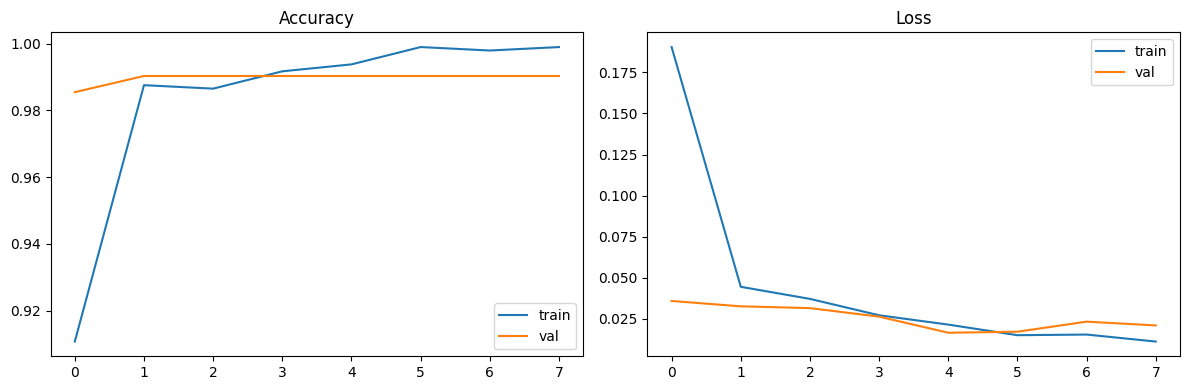

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='train')
ax1.plot(history.history['val_accuracy'], label='val')
ax1.set_title('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='train')
ax2.plot(history.history['val_loss'], label='val')
ax2.set_title('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

## 7. Takeaways

- VGG16 transfer learning hits ~96% accuracy vs ~60% from scratch (notebook 1)
- We only trained 4,097 parameters — the rest came free from ImageNet pretraining
- `preprocess_input` is not the same as `/255` — using the wrong one tanks accuracy
- Freezing all layers is the safe bet for tiny datasets (<2K images)
- EarlyStopping stopped training around epoch 5-7 — the model converges fast with frozen features
- **Bottom line:** Transfer learning >>> training from scratch when you have limited data

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,272,837 (512.21 MB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 134,260,544 (512.16 MB)

 Optimizer params: 8,196 (32.02 KB)